<a href="https://colab.research.google.com/github/HamzaEric/Weather_LSTMs_GRUs/blob/main/Notebooks/RNN_LSTM_GRU_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import random, numpy as np, torch
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import HTML, display
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

In [2]:
df = pd.read_csv("/content/drive/MyDrive/1_Daily_minimum_temps.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")
df["Temp"] = pd.to_numeric(df["Temp"], errors="coerce")
df = df.set_index("Date").dropna(subset=["Temp"])

In [3]:
# Time-aware split (1981–1988 train, 1989–1990 test)
split_date = pd.Timestamp("1989-01-01")
df_train = df.loc[: split_date - pd.Timedelta(days=1)]
df_test  = df.loc[split_date :]

In [4]:
# Scale with train-only fit (MinMax to [0,1])
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train[["Temp"]])
train_scaled = scaler.transform(df_train[["Temp"]])
test_scaled  = scaler.transform(df_test[["Temp"]])

In [5]:
def create_sliding_windows(series, window_size=7):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    X = np.array(X); y = np.array(y)
    return X.reshape((X.shape[0], X.shape[1], 1)), y.reshape((-1, 1))

WINDOW_SIZE = 7
X_train, y_train = create_sliding_windows(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sliding_windows(test_scaled,  WINDOW_SIZE)

In [6]:
# TensorDataset + DataLoader (batch-first)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


xb, yb = next(iter(train_loader))
print("Batch X shape (batch-first):", xb.shape)   # expect (B, 7, 1)
print("Batch y shape:", yb.shape)                 # expect (B, 1)

xb_time_first = xb.permute(1, 0, 2)
print("Time-first view of X:", xb_time_first.shape)  # (7, B, 1)

Batch X shape (batch-first): torch.Size([64, 7, 1])
Batch y shape: torch.Size([64, 1])
Time-first view of X: torch.Size([7, 64, 1])


# RNN DataFlow Visualization(D3.js)

In [7]:
path = "/content/drive/MyDrive/interactive_rnn_visualization.html"

with open(path, "r", encoding="utf-8") as f:
    html = f.read()

display(HTML(html))

# LSTM Data Flow Visualization

In [8]:
path = "/content/drive/MyDrive/interactive_lstm_cell_visualization.html"

with open(path, "r", encoding="utf-8") as f:
    html = f.read()

display(HTML(html))

# RNN(Baseline Model)

In [9]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, batch_first=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_first = batch_first

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity="tanh",     # default; explicit for clarity
            batch_first=batch_first,
            bidirectional=False
        )
        self.head = nn.Linear(hidden_size, 1)  # predict one value (next day)

    def forward(self, x):
        """
        x: (B, S, F) because we use batch_first=True (e.g., (B, 7, 1))
        returns: (B, 1)
        """
        B = x.size(0)

        # Initialize hidden state h0 per batch (layers, batch, hidden)
        h0 = torch.zeros(self.num_layers, B, self.hidden_size, device=x.device)

        # RNN forward: out has hidden for every time step
        out, hn = self.rnn(x, h0)   # out: (B, S, H) since batch_first=True

        # Take last time step’s hidden state
        h_last = out[:, -1, :]      # (B, H)

        # Linear head to scalar prediction
        y_hat = self.head(h_last)   # (B, 1)
        return y_hat


In [10]:
xb, yb = next(iter(train_loader))     # xb: (B, 7, 1), yb: (B, 1)

model_rnn = RNNModel(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
with torch.no_grad():
    y_hat = model_rnn(xb)
print("Input shape :", xb.shape)      # (B, 7, 1)
print("Output shape:", y_hat.shape)   # (B, 1)

Input shape : torch.Size([64, 7, 1])
Output shape: torch.Size([64, 1])


# **Main Model: LSTM**

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, batch_first=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_first = batch_first

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=batch_first,
            bidirectional=False,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        """
        x: (B, S, F) when batch_first=True (e.g., (B, 7, 1))
        returns: (B, 1)
        """
        B = x.size(0)
        # init states on the same device/dtype as x
        h0 = x.new_zeros(self.num_layers, B, self.hidden_size)
        c0 = x.new_zeros(self.num_layers, B, self.hidden_size)

        out, (hn, cn) = self.lstm(x, (h0, c0))   # out: (B, S, H) if batch_first=True
        # Option A: take last timestep from `out`
        h_last = out[:, -1, :]                   # (B, H)
        # Option B (equivalent): final layer's hidden state
        # h_last = hn[-1]                         # (B, H)

        y_hat = self.head(h_last)                # (B, 1)
        return y_hat

# Sanity run on a real batch
xb, yb = next(iter(train_loader))               # xb: (B, 7, 1)
model_lstm = LSTMModel(input_size=1, hidden_size=64, num_layers=1, batch_first=True).eval()

with torch.no_grad():
    y_hat = model_lstm(xb)

print("Input shape :", xb.shape)                # (B, 7, 1)
print("Output type :", type(y_hat))
print("Output shape:", y_hat.shape)             # (B, 1)
print("Example preds:", y_hat[:5].flatten())


Input shape : torch.Size([64, 7, 1])
Output type : <class 'torch.Tensor'>
Output shape: torch.Size([64, 1])
Example preds: tensor([-0.0403, -0.0399, -0.0389, -0.0403, -0.0414])


# GRU Data Flow Visualization

In [12]:
path = "/content/drive/MyDrive/interactive_GRU_visualizaton.html"

with open(path, "r", encoding="utf-8") as f:
    html = f.read()

display(HTML(html))

# GRU Model

In [13]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, batch_first=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_first = batch_first

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=batch_first,
            bidirectional=False
        )
        self.head = nn.Linear(hidden_size, 1)  # predict one value (next day)

    def forward(self, x):
        """
        x: (B, S, F) because we use batch_first=True (e.g., (B, 7, 1))
        returns: (B, 1)
        """
        B = x.size(0)

        # Initialize hidden state h0 (layers, batch, hidden), match device/dtype
        h0 = x.new_zeros(self.num_layers, B, self.hidden_size)

        # GRU forward:
        # out: (B, S, H) if batch_first=True
        # hn:  (layers, B, H) final hidden state
        out, hn = self.gru(x, h0)

        # Take the last time step’s hidden state
        h_last = out[:, -1, :]     # (B, H)

        # Linear head to scalar prediction
        y_hat = self.head(h_last)  # (B, 1)
        return y_hat

In [14]:
xb, yb = next(iter(train_loader))        # xb: (B, 7, 1), yb: (B, 1)

model_gru = GRUModel(input_size=1, hidden_size=64, num_layers=1, batch_first=True).eval()
with torch.no_grad():
    y_hat = model_gru(xb)

print("Input shape :", xb.shape)         # (B, 7, 1)
print("Output shape:", y_hat.shape)      # (B, 1)
print("Example preds:", y_hat[:5].flatten())

Input shape : torch.Size([64, 7, 1])
Output shape: torch.Size([64, 1])
Example preds: tensor([-0.0151, -0.0185, -0.0107, -0.0193, -0.0108])


In [15]:
def train_one_model(model, train_loader, val_loader, epochs=20, lr=1e-3, clip=None, verbose=True):
    """
    Train a sequence model (RNN/LSTM/GRU head) on scaled targets.
    Assumes:
      - inputs:  (B, S, F) with batch_first=True (as built in our loaders)
      - targets: (B, 1), scaled to [0,1]
    Returns:
      model (trained in-place), history: {'train_loss': [...], 'val_loss': [...]}
    """
    device = torch.device("cpu")  # CPU-only per project constraints
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        running = 0.0
        n = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            y_hat = model(xb)
            loss = criterion(y_hat, yb)
            loss.backward()

            if clip is not None:
                clip_grad_norm_(model.parameters(), max_norm=clip)

            optimizer.step()

            running += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = running / max(n, 1)
        history["train_loss"].append(train_loss)

        # ---- Validate ----
        model.eval()
        running = 0.0
        n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device); yb = yb.to(device)
                y_hat = model(xb)
                loss = criterion(y_hat, yb)
                running += loss.item() * xb.size(0)
                n += xb.size(0)
        val_loss = running / max(n, 1)
        history["val_loss"].append(val_loss)

        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == epochs):
            print(f"Epoch {epoch:02d}/{epochs} | train {train_loss:.6f} | val {val_loss:.6f}")

    return model, history

def plot_loss(history, title="Training vs Validation Loss"):
    """Plot train/val loss curves for a single model."""
    plt.figure(figsize=(7,4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (scaled space)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    # x ticks from 1 to len(history) with step 1
    plt.xticks(range(0, len(history["train_loss"]), 1))
    plt.tight_layout()
    plt.show()

Epoch 01/20 | train 0.054396 | val 0.016825
Epoch 05/20 | train 0.010560 | val 0.008450
Epoch 10/20 | train 0.009703 | val 0.007801
Epoch 15/20 | train 0.009289 | val 0.007846
Epoch 20/20 | train 0.009122 | val 0.007203


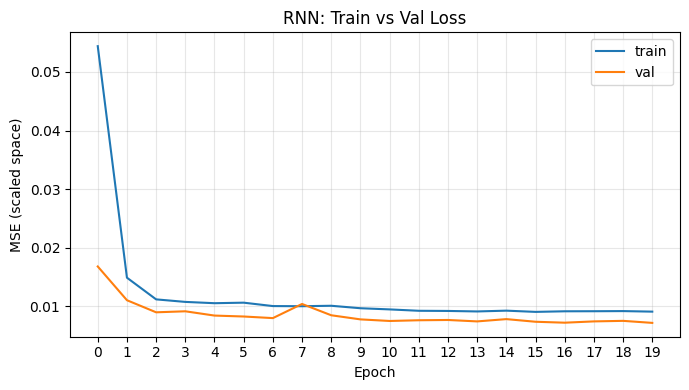

Epoch 01/20 | train 0.042220 | val 0.020126
Epoch 05/20 | train 0.011628 | val 0.009622
Epoch 10/20 | train 0.011004 | val 0.009067
Epoch 15/20 | train 0.010304 | val 0.008476
Epoch 20/20 | train 0.009601 | val 0.007664


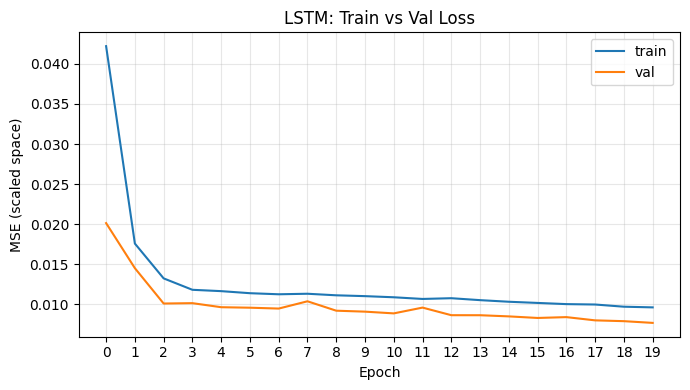

Epoch 01/20 | train 0.041856 | val 0.020230
Epoch 05/20 | train 0.010770 | val 0.008868
Epoch 10/20 | train 0.009987 | val 0.008174
Epoch 15/20 | train 0.009386 | val 0.007542
Epoch 20/20 | train 0.009224 | val 0.007486


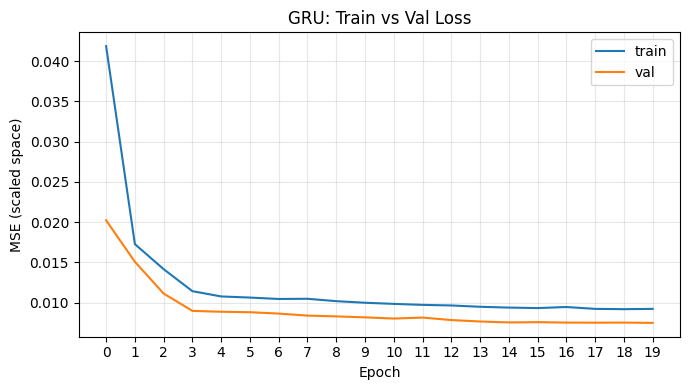

In [16]:
EPOCHS = 20
LR     = 1e-3
CLIP   = 1.0

# RNN baseline
model_rnn = RNNModel(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
model_rnn, hist_rnn = train_one_model(model_rnn, train_loader, test_loader, epochs=EPOCHS, lr=LR, clip=CLIP)
plot_loss(hist_rnn, title="RNN: Train vs Val Loss")

# LSTM
model_lstm = LSTMModel(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
model_lstm, hist_lstm = train_one_model(model_lstm, train_loader, test_loader, epochs=EPOCHS, lr=LR, clip=CLIP)
plot_loss(hist_lstm, title="LSTM: Train vs Val Loss")

# GRU
model_gru = GRUModel(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
model_gru, hist_gru = train_one_model(model_gru, train_loader, test_loader, epochs=EPOCHS, lr=LR, clip=CLIP)
plot_loss(hist_gru, title="GRU: Train vs Val Loss")

# **Inference & Metrics in °C**

**What we are doing :**
We will take the models we trained on **scaled values** (range $[0,1]$), generate predictions on the **test set**, and then **invert the scaling** with the *same fitted scaler* from NB01 so that both predictions and targets are back in **degrees Celsius**.

Why this matters:
- Training in the scaled space gives us **stable gradients**.
- Reporting in **°C** makes errors **interpretable** (e.g., “off by $1.1^\circ\text{C}$ on average”).

We will compute:
- **MAE** (Mean Absolute Error) in $^\circ\text{C}$,
- **RMSE** (Root Mean Squared Error) in $^\circ\text{C}$,
- optionally $R^2$ for an “explained variance” view.

And we will visualize a **line plot** of actual vs predicted for the first 200 test points,

> we must call the scaler’s `inverse_transform` on **both** $y_{\text{true}}$ and $y_{\text{pred}}$ using the **same scaler** that was fit on the **training** data (NB01). Using a different scaler or refitting on test would cause leakage or mismatched units.

In [18]:
def predict_on_loader(model, loader):
    """
    Returns:
      y_true_scaled: (N, 1)
      y_pred_scaled: (N, 1)
    """
    model.eval()
    ys, yhs = [], []
    with torch.no_grad():
        for xb, yb in loader:
            yhat = model(xb)
            ys.append(yb.cpu().numpy())
            yhs.append(yhat.cpu().numpy())
    y_true_scaled = np.vstack(ys)
    y_pred_scaled = np.vstack(yhs)
    return y_true_scaled, y_pred_scaled


def inverse_to_celsius(arr_scaled, scaler):
    """arr_scaled: (N,1) → inverse_transform → (N,1) in °C"""
    return scaler.inverse_transform(arr_scaled)


def evaluate_in_celsius(model, loader, scaler):
    """
    Returns:
      metrics dict and (y_true_C, y_pred_C) arrays, each (N,1)
    """
    y_s, yhat_s = predict_on_loader(model, loader)
    y_C    = inverse_to_celsius(y_s,    scaler)
    yhat_C = inverse_to_celsius(yhat_s, scaler)

    mae  = mean_absolute_error(y_C, yhat_C)
    mse  = mean_squared_error(y_C, yhat_C)
    rmse = mse ** 0.5
    r2   = r2_score(y_C, yhat_C)

    metrics = {"MAE_C": float(mae), "RMSE_C": float(rmse), "R2": float(r2)}
    return metrics, y_C, yhat_C


def plot_line_slice(y_C, yhat_C, first_n=200, title="Actual vs Predicted (°C) — first 200 test points"):
    n = min(first_n, len(y_C))
    plt.figure(figsize=(10,4))
    plt.plot(y_C[:n],    label="Actual (°C)")
    plt.plot(yhat_C[:n], label="Predicted (°C)")
    plt.xlabel("Test index")
    plt.ylabel("Temperature (°C)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

RNN: {'MAE_C': 1.7486093044281006, 'RMSE_C': 2.232144182477285, 'R2': 0.7039487361907959}


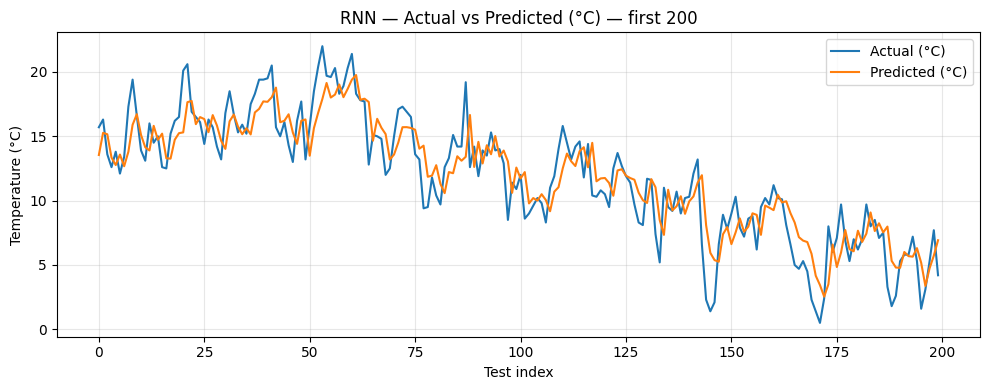

LSTM: {'MAE_C': 1.7971127033233643, 'RMSE_C': 2.3024505621524223, 'R2': 0.6850054264068604}


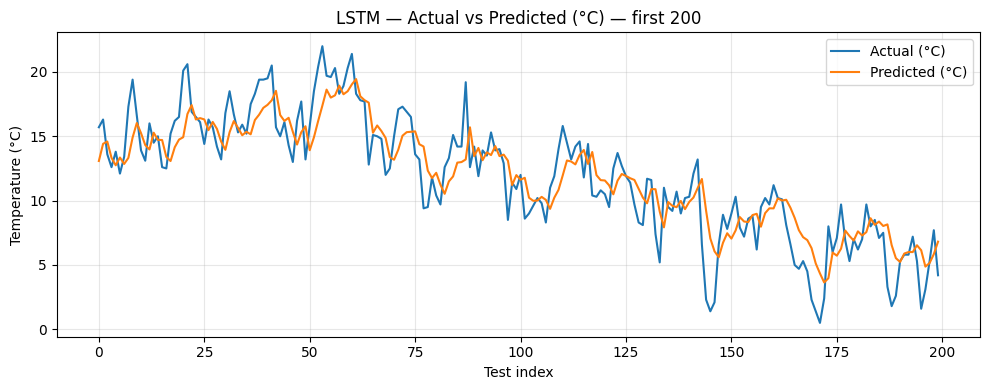

GRU: {'MAE_C': 1.785549283027649, 'RMSE_C': 2.2755024239902917, 'R2': 0.6923357248306274}


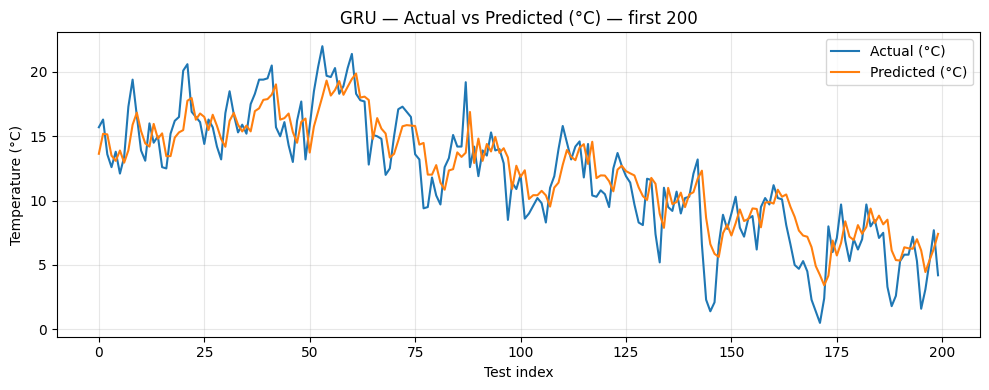

In [19]:
# RNN
metrics_rnn, yC_rnn, yhC_rnn = evaluate_in_celsius(model_rnn, test_loader, scaler)
print("RNN:", metrics_rnn)
plot_line_slice(yC_rnn, yhC_rnn, first_n=200, title="RNN — Actual vs Predicted (°C) — first 200")

# LSTM
metrics_lstm, yC_lstm, yhC_lstm = evaluate_in_celsius(model_lstm, test_loader, scaler)
print("LSTM:", metrics_lstm)
plot_line_slice(yC_lstm, yhC_lstm, first_n=200, title="LSTM — Actual vs Predicted (°C) — first 200")

# GRU
metrics_gru, yC_gru, yhC_gru = evaluate_in_celsius(model_gru, test_loader, scaler)
print("GRU:", metrics_gru)
plot_line_slice(yC_gru, yhC_gru, first_n=200, title="GRU — Actual vs Predicted (°C) — first 200")

# Moving Average 7 for another baseline comparison

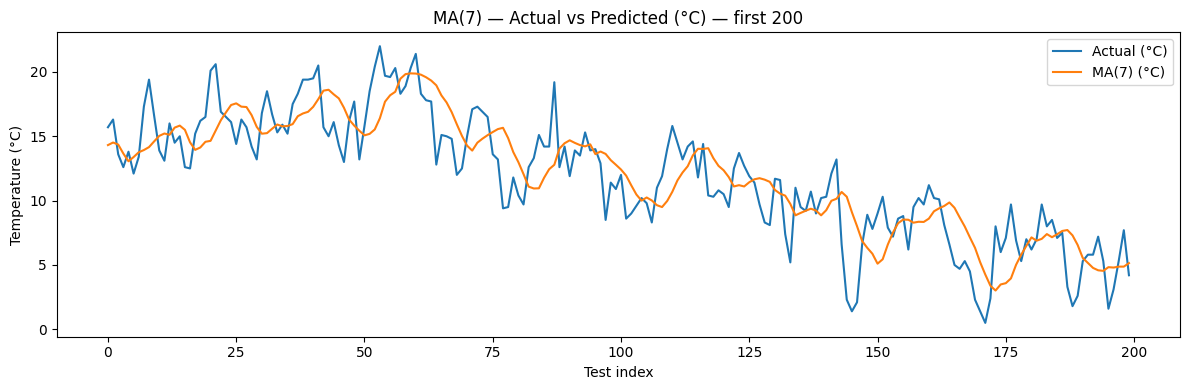

In [20]:
# MA(7) prediction for each test window (still in scaled space)
yhat_ma_test_scaled = X_test.mean(axis=1)  # shape: (N_test, 1)

# Invert scaling to °C to match the RNN plot
y_true_c = scaler.inverse_transform(y_test).squeeze()
yhat_ma_c = scaler.inverse_transform(yhat_ma_test_scaled).squeeze()

# Plot first 200 like the RNN figure
n = 200
plt.figure(figsize=(12,4))
plt.plot(np.arange(n), y_true_c[:n], label="Actual (°C)")
plt.plot(np.arange(n), yhat_ma_c[:n], label="MA(7) (°C)")
plt.title("MA(7) — Actual vs Predicted (°C) — first 200")
plt.xlabel("Test index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

### **Side-by-Side Comparison (RNN vs LSTM vs GRU)**

**What we compare**

We’ll line up the **test metrics in °C** (MAE, RMSE, $R^2$) for all three models and then overlay the **validation loss curves** to see learning dynamics.  
Interpretation guide:

- **MAE/RMSE (°C):** smaller is better. RMSE penalizes large errors more.  
- **$R^2$:** closer to $1$ is better.  
- **Val-loss curves:** faster/steadier descent suggests easier optimization or right capacity.

**Why gates help (big picture):**  
Gated cells (LSTM/GRU) create a **longer effective memory** and **stabler gradients**. With short windows ($S=7$), the benefit may be small; with longer context or more volatile regimes, we expect the advantage to grow.

In [21]:
# === MA(7) baseline on validation (fallback to test if no val set) ===
X_eval = X_val if 'X_val' in globals() else X_test
y_eval = y_val if 'y_val' in globals() else y_test

# MA(7) prediction in *scaled* space to match val_loss
yhat_ma_eval_scaled = X_eval.mean(axis=1)                    # (N,1)
val_mse_ma = float(np.mean((y_eval.squeeze() - yhat_ma_eval_scaled.squeeze())**2))

# Also compute metrics in °C for the table
y_eval_C  = scaler.inverse_transform(y_eval).ravel()
yhat_ma_C = scaler.inverse_transform(yhat_ma_eval_scaled).ravel()
metrics_ma = {
    "MAE_C":  float(np.mean(np.abs(y_eval_C - yhat_ma_C))),
    "RMSE_C": float(np.sqrt(np.mean((y_eval_C - yhat_ma_C)**2))),
    "R2":     float(r2_score(y_eval_C, yhat_ma_C)),
}

,MAE_C,RMSE_C,R2
RNN,1.749,2.232,0.704
GRU,1.786,2.276,0.692
LSTM,1.797,2.302,0.685
MA(7),2.029,2.583,0.604


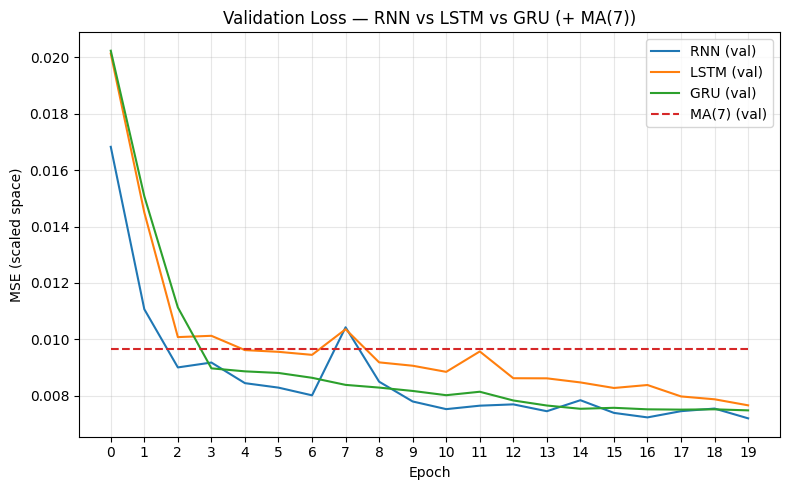

In [22]:
# --- Metrics table (now includes MA(7)) ---
df_metrics = pd.DataFrame.from_dict(
    {
        "RNN":   metrics_rnn,
        "LSTM":  metrics_lstm,
        "GRU":   metrics_gru,
        "MA(7)": metrics_ma,
    },
    orient="index",
)
df_metrics = df_metrics[["MAE_C", "RMSE_C", "R2"]]
display(df_metrics.sort_values("RMSE_C").round(3))

# --- Validation curves + MA(7) flat line ---
plt.figure(figsize=(8,5))
plt.plot(hist_rnn["val_loss"],  label="RNN (val)")
plt.plot(hist_lstm["val_loss"], label="LSTM (val)")
plt.plot(hist_gru["val_loss"],  label="GRU (val)")

E = len(hist_rnn["val_loss"])
plt.plot([val_mse_ma]*E, label="MA(7) (val)", linestyle="--")  # flat baseline

plt.xlabel("Epoch")
plt.ylabel("MSE (scaled space)")
plt.title("Validation Loss — RNN vs LSTM vs GRU (+ MA(7))")
plt.xticks(range(0, E, 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("RNN params :", count_params(model_rnn))
print("LSTM params:", count_params(model_lstm))
print("GRU params :", count_params(model_gru))

RNN params : 4353
LSTM params: 17217
GRU params : 12929


In [25]:
drive_path = "/content/drive/MyDrive/rnn_gated_models"


os.makedirs(drive_path, exist_ok=True)

torch.save(model_rnn.state_dict(),  os.path.join(drive_path, "rnn_state.pkl"))
torch.save(model_lstm.state_dict(), os.path.join(drive_path, "lstm_state.pkl"))
torch.save(model_gru.state_dict(),  os.path.join(drive_path, "gru_state.pkl"))

print(f"Saved files in {drive_path}:")
print(os.listdir(drive_path))

Saved files in /content/drive/MyDrive/rnn_gated_models:
['rnn_state.pkl', 'lstm_state.pkl', 'gru_state.pkl']
